# Model 1: SBI-Inspired Artifact Detector — Kaggle (background-run build)

EfficientNet-B0 trained on self-blended diverse real faces (FairFace + UTKFace), SAM optimizer.
Note: SBI paper (Shiohara & Yamasaki, CVPR 2022) used EfficientNet-B4; B0 is a deliberate downscale for the T4 memory profile.
Held-out eval on Celeb-DF v2. Target: AUC ≥ 0.80 on the spatial-artifact / face-swap lane.

**This build is configured to run end-to-end unattended.** Every knob lives in the
CONFIG cell below. No monkeypatching, no cell that no-ops silently, no manual checkpoint
deletion needed (resume is config-tagged).

**Before running:**
- Enable GPU: Settings → Accelerator → GPU T4.
- Add Celeb-DF v2 as a dataset input (appears under `/kaggle/input/`).
- OpenForensics fine-tune and ROSE cross-scope check are auto-skipped if absent.

In [1]:
# ============================ CONFIG (single source of truth) ============================
# Change one variable per experiment. Bump RUN_TAG whenever the training distribution
# changes (dataset size, augmentation, blend logic) so stale checkpoints are ignored.

import torch, os

BASE     = '/kaggle/working/deepfake_project'
RUN_TAG  = 'sam_shared_degrade_60k_v1'    # <-- distribution identity; checkpoints from other tags are ignored

# --- data ---
IMG_SIZE        = 224          # SBI boundary artifacts need resolution
MAX_REAL_IMAGES = 60_000       # Kaggle T4 disk budget: 60k fits (~12GB cache); 100k use on 4090 (set RUN_TAG accordingly)
VAL_FRACTION    = 0.10

# --- training ---
EPOCHS          = 20
BATCH_SIZE      = 64           # proven single-T4 profile; DP+128 OOM'd host RAM (2026-06-11)
LR              = 1e-4
WEIGHT_DECAY    = 1e-5
SAM_RHO         = 0.05
NUM_WORKERS     = 4

# --- early stop (val AUC plateau) ---
EARLY_STOP_PATIENCE = 4        # stop if no val-AUC improvement for this many epochs
EARLY_STOP_MIN_DELTA = 1e-3

# --- OpenForensics fine-tune (auto-skipped if dataset absent) ---
DO_OPENFORENSICS_FT = True
OF_MAX_PER_CLASS    = 5000
OF_EPOCHS           = 3
OF_LR               = 1e-5

# --- Celeb-DF eval ---
EVAL_N_PER_CLASS = 200
EVAL_N_FRAMES    = 32

SEED = 42
import random, numpy as np
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU — enable in Settings > Accelerator'}")

for d in [
    f'{BASE}/datasets/FairFace', f'{BASE}/datasets/UTKFace',
    f'{BASE}/datasets/CelebDF/real', f'{BASE}/datasets/CelebDF/fake',
    f'{BASE}/datasets/OpenForensics/real', f'{BASE}/datasets/OpenForensics/fake',
    f'{BASE}/models/model1', f'{BASE}/results/model1',
]:
    os.makedirs(d, exist_ok=True)

MODEL_DIR   = f'{BASE}/models/model1'
RESULTS_DIR = f'{BASE}/results/model1'
print("Directories ready. RUN_TAG =", RUN_TAG)
print(f"Kaggle inputs: {os.listdir('/kaggle/input/') if os.path.exists('/kaggle/input/') else 'none'}")

GPU: Tesla T4
Directories ready. RUN_TAG = sam_shared_degrade_60k_v1
Kaggle inputs: ['notebooks', 'datasets']


## Install Dependencies

In [2]:
!pip install -q timm albumentations gdown scikit-learn tqdm pillow datasets 'mediapipe>=0.10.9'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 58.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you hav

## Download FairFace
Racially balanced across 7 groups. Downloads via gdown.

In [3]:
import gdown, zipfile, os
from pathlib import Path

FAIRFACE_DIR = f'{BASE}/datasets/FairFace'

if not os.path.exists(f'{FAIRFACE_DIR}/train'):
    print("Downloading FairFace train images (~3GB)...")
    gdown.download('https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86',
                   f'{FAIRFACE_DIR}/fairface_train.zip', quiet=False)
    with zipfile.ZipFile(f'{FAIRFACE_DIR}/fairface_train.zip', 'r') as z:
        z.extractall(FAIRFACE_DIR)
    os.remove(f'{FAIRFACE_DIR}/fairface_train.zip')
    print("Extracted.")
else:
    print("FairFace already present.")

for fid, fname in [
    ('1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH', 'fairface_label_train.csv'),
    ('1wOdja-ezstMEp81tX1a-EYkFebev4h7D', 'fairface_label_val.csv'),
]:
    dest = f'{FAIRFACE_DIR}/{fname}'
    if not os.path.exists(dest):
        gdown.download(f'https://drive.google.com/uc?id={fid}', dest, quiet=False)

n = len(list(Path(f'{FAIRFACE_DIR}/train').rglob('*.jpg')))
print(f"FairFace ready: {n:,} images.")

Downloading...
From (original): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86
From (redirected): https://drive.google.com/uc?id=1Z1RqRo0_JiavaZw2yzZG6WETdZQ8qX86&confirm=t&uuid=bf4d0e4e-678f-40d4-9025-409c87d9d441
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_train.zip
100%|██████████| 578M/578M [00:05<00:00, 114MB/s]


Extracted.


Downloading...
From: https://drive.google.com/uc?id=1i1L3Yqwaio7YSOCj7ftgk8ZZchPG7dmH
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_label_train.csv
100%|██████████| 3.79M/3.79M [00:00<00:00, 86.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1wOdja-ezstMEp81tX1a-EYkFebev4h7D
To: /kaggle/working/deepfake_project/datasets/FairFace/fairface_label_val.csv
100%|██████████| 448k/448k [00:00<00:00, 4.78MB/s]


FairFace ready: 86,744 images.


## Download UTKFace
Via HuggingFace `py97/UTKFace-Cropped`.

In [4]:
from datasets import load_dataset
from pathlib import Path
import os, cv2, numpy as np

UTK_DIR = f'{BASE}/datasets/UTKFace'
os.makedirs(UTK_DIR, exist_ok=True)

# Stream UTKFace from HuggingFace and write a single compact npy instead of
# individual JPEGs (~0.7 GB saved vs per-file approach on /kaggle/working).
UTK_NPY = f'{UTK_DIR}/images.npy'

if os.path.exists(UTK_NPY):
    arr = np.load(UTK_NPY, mmap_mode='r')
    print(f"UTKFace already cached: {len(arr):,} images ({os.path.getsize(UTK_NPY)/1e9:.2f} GB)")
else:
    print("Streaming UTKFace from HuggingFace into compact npy...")
    ds = load_dataset("py97/UTKFace-Cropped", split="train")
    # pre-allocate; UTKFace-Cropped has ~23k images
    buf = np.empty((len(ds), IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    j = 0
    for i, item in enumerate(ds):
        img = item.get('jpg.chip.jpg')
        if img is None:
            continue
        arr_img = np.array(img.convert('RGB'))
        buf[j] = cv2.resize(arr_img, (IMG_SIZE, IMG_SIZE))
        j += 1
        if i % 2000 == 0:
            print(f"  {i}/{len(ds)} ({j} saved)")
    np.save(UTK_NPY, buf[:j])
    print(f"UTKFace ready: {j:,} images saved to {UTK_NPY} "
          f"({os.path.getsize(UTK_NPY)/1e9:.2f} GB)")


Streaming UTKFace from HuggingFace into compact npy...


README.md:   0%|          | 0.00/795 [00:00<?, ?B/s]

UTKFace.tar.gz:   0%|          | 0.00/107M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/23708 [00:00<?, ? examples/s]

  0/23708 (1 saved)
  2000/23708 (2001 saved)
  4000/23708 (4001 saved)
  6000/23708 (6000 saved)
  8000/23708 (8000 saved)
  10000/23708 (10000 saved)
  12000/23708 (12000 saved)
  14000/23708 (14000 saved)
  16000/23708 (16000 saved)
  18000/23708 (18000 saved)
  20000/23708 (20000 saved)
  22000/23708 (22000 saved)
UTKFace ready: 23,707 images saved to /kaggle/working/deepfake_project/datasets/UTKFace/images.npy (3.57 GB)


## Locate Celeb-DF v2
Eval-only. Reads video paths from the Kaggle dataset input.

In [5]:
from pathlib import Path

CELEBDF_REAL_DIRS = [
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-real',
    '/kaggle/input/datasets/ramyakin/celeb-df-v2/YouTube-real',
]
CELEBDF_FAKE_DIR = '/kaggle/input/datasets/ramyakin/celeb-df-v2/Celeb-synthesis'

real_vids = []
for d in CELEBDF_REAL_DIRS:
    real_vids += list(Path(d).rglob('*.mp4'))
fake_vids = list(Path(CELEBDF_FAKE_DIR).rglob('*.mp4'))
print(f"Celeb-DF v2  Real: {len(real_vids)} | Fake: {len(fake_vids)}")
if not real_vids or not fake_vids:
    print("  (not found yet — eval cell will skip cleanly if still empty at run time)")

Celeb-DF v2  Real: 890 | Fake: 5639


## SBI Blending Pipeline
Landmark convex-hull masks via MediaPipe Tasks API (`.task` file; legacy `mp.solutions` is absent
in current mediapipe). Elliptical mask is a fallback only when no face is found.

`_shared_degrade()` applies JPEG round-trip + downscale to **both** classes in `__getitem__`.
This removes the label-correlated shortcut (fake-only compression made the model learn
`compression == fake`, which inverted on Celeb-DF reals carrying H.264 + upscaled crops).
`source_aug` is unchanged — the source/target *relative* mismatch is the legitimate SBI signal.

In [6]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['GLOG_minloglevel'] = '3'

import cv2
cv2.setNumThreads(0)
import numpy as np
import albumentations as A
import random
import urllib.request

source_aug = A.Compose([
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.8),
    A.HueSaturationValue(hue_shift_limit=20, sat_shift_limit=30, val_shift_limit=20, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.GaussianBlur(blur_limit=(3, 7), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
    A.Downscale(scale_range=(0.7, 0.9), p=0.3),   # source/target resolution mismatch
])

def get_face_mask(h, w):
    """Fallback elliptical mask (used only when no landmarks are found)."""
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.ellipse(mask, (w // 2, h // 2), (int(w * 0.40), int(h * 0.52)), 0, 0, 360, 255, -1)
    return mask

# ---- Landmark hull masks (MediaPipe Tasks API) ----
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

_TASK_PATH = '/kaggle/working/face_landmarker.task'
if not os.path.exists(_TASK_PATH):
    urllib.request.urlretrieve(
        'https://storage.googleapis.com/mediapipe-models/face_landmarker/'
        'face_landmarker/float16/1/face_landmarker.task', _TASK_PATH)

def make_face_mesh():
    opts = vision.FaceLandmarkerOptions(
        base_options=mp_python.BaseOptions(model_asset_path=_TASK_PATH),
        running_mode=vision.RunningMode.IMAGE, num_faces=1,
        min_face_detection_confidence=0.3)
    return vision.FaceLandmarker.create_from_options(opts)

def landmark_hull_mask(img_rgb, mesh):
    """Binary convex-hull mask (0/255) from FaceLandmarker, or None if no face."""
    h, w = img_rgb.shape[:2]
    mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=np.ascontiguousarray(img_rgb))
    res = mesh.detect(mp_img)
    if not res.face_landmarks:
        return None
    pts  = np.array([(lm.x * w, lm.y * h) for lm in res.face_landmarks[0]], dtype=np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillConvexPoly(mask, cv2.convexHull(pts), 255)
    return mask

def deform_mask(mask_u8):
    """SBI mask randomisation: erode/dilate, affine jitter, soft edge, random blend ratio."""
    m = mask_u8.copy()
    k = random.choice([0, 5, 9, 13, 17])
    if k:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
        m = cv2.dilate(m, kernel) if random.random() < 0.5 else cv2.erode(m, kernel)
    h, w = m.shape
    pts0 = np.float32([[0, 0], [w, 0], [0, h]])
    pts1 = pts0 + np.random.uniform(-0.03, 0.03, pts0.shape).astype(np.float32) * w
    m    = cv2.warpAffine(m, cv2.getAffineTransform(pts0, pts1), (w, h))
    blur = random.choice([15, 23, 31, 47])
    m    = cv2.GaussianBlur(m, (blur, blur), 0).astype(np.float32) / 255.0
    r    = random.choice([0.25, 0.5, 0.75, 1.0, 1.0, 1.0])
    return m * r

def _shared_degrade(img):
    """Label-independent degradations applied to BOTH classes (kills the compression shortcut)."""
    h, w = img.shape[:2]
    if random.random() < 0.3:   # downscale-upscale
        s = random.uniform(0.5, 0.9)
        small = cv2.resize(img, (int(w * s), int(h * s)),
                           interpolation=random.choice([cv2.INTER_LINEAR, cv2.INTER_AREA]))
        img = cv2.resize(small, (w, h),
                         interpolation=random.choice([cv2.INTER_LINEAR, cv2.INTER_CUBIC]))
    if random.random() < 0.5:   # JPEG round-trip q30-90
        q = random.randint(30, 90)
        _, buf = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                              [cv2.IMWRITE_JPEG_QUALITY, q])
        img = cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)
    return img

print("SBI pipeline ready (landmark masks, IMG_SIZE =", IMG_SIZE, ")")

E0000 00:00:1781830450.520751      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781830450.572665      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781830451.032460      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781830451.032503      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781830451.032506      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781830451.032508      23 computation_placer.cc:177] computation placer already registered. Please check linka

SBI pipeline ready (landmark masks, IMG_SIZE = 224 )


## Dataset and Transforms

In [7]:
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

train_tf = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=10, p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])
val_tf = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

class SBIDataset(Dataset):
    # cache key = RUN_TAG + max_images; stale caches from other tags are ignored
    def __init__(self, real_dirs, transform=None, max_images=None):
        if isinstance(real_dirs, str):
            real_dirs = [real_dirs]
        tag = f'{RUN_TAG}_{max_images}'
        self.CACHE_IMG  = f'/kaggle/working/sbi_imgs_{tag}.npy'
        self.CACHE_MASK = f'/kaggle/working/sbi_masks_{tag}.npy'
        self.CACHE_N    = f'/kaggle/working/sbi_count_{tag}.npy'

        if os.path.exists(self.CACHE_IMG) and os.path.exists(self.CACHE_N):
            print("Loading memory-mapped cache:", self.CACHE_IMG)
            j = int(np.load(self.CACHE_N))
            self.images     = np.load(self.CACHE_IMG,  mmap_mode='r')[:j]
            self.face_masks = np.load(self.CACHE_MASK, mmap_mode='r')[:j]
            print(f"Loaded {len(self.images):,} from cache.")
        else:
            # real_dirs entries are either a directory of JPEGs or a .npy array
            # (UTKFace is stored as images.npy to avoid ~23k individual files on /working)
            paths, npy_arrays = [], []
            for d in real_dirs:
                if str(d).endswith('.npy') and os.path.exists(d):
                    arr = np.load(d, mmap_mode='r')
                    npy_arrays.append(arr)
                    print(f"  {Path(d).name}: {len(arr):,} pre-resized images (npy)")
                elif os.path.exists(d):
                    found = list(Path(d).rglob('*.jpg')) + list(Path(d).rglob('*.png'))
                    paths += found
                    print(f"  {Path(d).name}: {len(found):,} images")

            total_available = sum(len(a) for a in npy_arrays) + len(paths)
            n = min(max_images, total_available) if max_images else total_available
            print(f"Building memmap cache for {n:,} images (budget: {n * IMG_SIZE * IMG_SIZE * 4 / 1e9:.1f} GB)...")

            imgs  = np.lib.format.open_memmap(self.CACHE_IMG,  mode='w+',
                        dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE, 3))
            masks = np.lib.format.open_memmap(self.CACHE_MASK, mode='w+',
                        dtype=np.uint8, shape=(n, IMG_SIZE, IMG_SIZE))
            mesh = make_face_mesh()
            j, n_fallback = 0, 0

            # 1) consume pre-resized npy arrays (UTKFace – already IMG_SIZE x IMG_SIZE)
            for arr in npy_arrays:
                for img in tqdm(arr, desc='npy (UTKFace)'):
                    if j >= n: break
                    mask = landmark_hull_mask(img, mesh)
                    if mask is None:
                        mask = get_face_mask(IMG_SIZE, IMG_SIZE); n_fallback += 1
                    imgs[j], masks[j] = img, mask
                    j += 1

            # 2) consume individual JPEG files (FairFace), shuffle for class balance
            if j < n:
                random.shuffle(paths)
                for p in tqdm(paths, desc='jpg (FairFace)'):
                    if j >= n: break
                    img = cv2.imread(str(p))
                    if img is None:
                        continue
                    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                    mask = landmark_hull_mask(img, mesh)
                    if mask is None:
                        mask = get_face_mask(IMG_SIZE, IMG_SIZE); n_fallback += 1
                    imgs[j], masks[j] = img, mask
                    j += 1

            mesh.close()
            imgs.flush(); masks.flush()
            np.save(self.CACHE_N, np.array(j))
            print(f"Cached {j:,} ({n_fallback:,} ellipse fallbacks)")
            del imgs, masks
            self.images     = np.load(self.CACHE_IMG,  mmap_mode='r')[:j]
            self.face_masks = np.load(self.CACHE_MASK, mmap_mode='r')[:j]
        self.transform = transform

    def __len__(self):
        return len(self.images) * 2

    def __getitem__(self, idx):
        img      = np.array(self.images[idx // 2])
        use_real = (idx % 2 == 1)
        if use_real:
            return _shared_degrade(img), torch.tensor(1.0)

        h, w   = img.shape[:2]
        mask   = deform_mask(np.array(self.face_masks[idx // 2]))
        source = source_aug(image=img.copy())['image']
        if random.random() > 0.5:
            src_pts = np.float32([[0,0],[w-1,0],[0,h-1],[w-1,h-1]])
            dst_pts = src_pts + np.random.uniform(-14, 14, src_pts.shape).astype(np.float32)
            source  = cv2.warpPerspective(source, cv2.getPerspectiveTransform(src_pts, dst_pts),
                                          (w, h), borderMode=cv2.BORDER_REPLICATE)
        mask3 = mask[..., None]
        blend = (source * mask3 + img * (1 - mask3)).astype(np.uint8)
        return _shared_degrade(blend), torch.tensor(0.0)


class OpenForensicsDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None, max_per_class=None):
        real = list(Path(real_dir).rglob('*.jpg')) + list(Path(real_dir).rglob('*.png'))
        fake = list(Path(fake_dir).rglob('*.jpg')) + list(Path(fake_dir).rglob('*.png'))
        if max_per_class:
            real, fake = real[:max_per_class], fake[:max_per_class]
        self.items     = [(p, 1) for p in real] + [(p, 0) for p in fake]
        self.transform = transform
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        path, label = self.items[idx]
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        return img, torch.tensor(float(label))


class WithTransform(Dataset):
    def __init__(self, subset, tf):
        self.subset, self.tf = subset, tf
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, i):
        img, label = self.subset[i]
        if isinstance(img, np.ndarray):
            img = self.tf(image=img)['image']
        return img, label

print("Dataset classes ready.")


Dataset classes ready.


## Model: EfficientNet-B0

In [8]:
import timm
import torch.nn as nn

class ArtifactDetector(nn.Module):
    def __init__(self, backbone='efficientnet_b0', pretrained=True):
        super().__init__()
        self.net = timm.create_model(backbone, pretrained=pretrained, num_classes=1)
    def forward(self, x):
        return self.net(x).squeeze(-1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = ArtifactDetector().to(device)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Device: {device}")
print(f"Total params: {total:,} | Trainable: {trainable:,}")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Device: cuda
Total params: 4,008,829 | Trainable: 4,008,829


## Training
SAM optimizer (Foret et al., ICLR 2021). 20-epoch budget with val-AUC plateau early stop
(patience from CONFIG). Checkpoint resume is gated on `RUN_TAG`; a checkpoint already at
`EPOCHS` reports done and skips cleanly rather than no-op'ing.

In [9]:
import torch.optim as optim
from torch.amp import GradScaler, autocast
from sklearn.metrics import roc_auc_score
import json

REAL_DIRS = [f'{BASE}/datasets/FairFace/train', f'{BASE}/datasets/UTKFace/images.npy']

full_ds = SBIDataset(REAL_DIRS, transform=None, max_images=MAX_REAL_IMAGES)
val_n   = int(VAL_FRACTION * len(full_ds))
train_n = len(full_ds) - val_n
train_ds, val_ds = torch.utils.data.random_split(
    full_ds, [train_n, val_n], generator=torch.Generator().manual_seed(SEED))

def worker_init(_):
    cv2.setNumThreads(0)

print(f"GPUs visible: {torch.cuda.device_count()} | using 1 | train batch: {BATCH_SIZE}")
train_loader = DataLoader(WithTransform(train_ds, train_tf), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True,
                          prefetch_factor=2, worker_init_fn=worker_init)
val_loader   = DataLoader(WithTransform(val_ds, val_tf), batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=False,
                          worker_init_fn=worker_init)

# ---- SAM (Foret et al., ICLR 2021) ----
class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        super().__init__(params, dict(rho=rho, **kwargs))
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups
        self.defaults.update(self.base_optimizer.defaults)
    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group['rho'] / (grad_norm + 1e-12)
            for p in group['params']:
                if p.grad is None: continue
                e_w = p.grad * scale.to(p)
                p.add_(e_w); self.state[p]['e_w'] = e_w
        if zero_grad: self.zero_grad()
    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group['params']:
                if p.grad is None or 'e_w' not in self.state[p]: continue
                p.sub_(self.state[p]['e_w'])
        self.base_optimizer.step()
        if zero_grad: self.zero_grad()
    def _grad_norm(self):
        dev = self.param_groups[0]['params'][0].device
        return torch.norm(torch.stack([
            p.grad.norm(p=2).to(dev) for group in self.param_groups
            for p in group['params'] if p.grad is not None]), p=2)

def _set_bn_momentum_zero(m):
    for mod in m.modules():
        if isinstance(mod, nn.modules.batchnorm._BatchNorm):
            mod.backup_momentum = mod.momentum; mod.momentum = 0
def _restore_bn_momentum(m):
    for mod in m.modules():
        if isinstance(mod, nn.modules.batchnorm._BatchNorm) and hasattr(mod, 'backup_momentum'):
            mod.momentum = mod.backup_momentum

optimizer = SAM(model.parameters(), optim.Adam, rho=SAM_RHO, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
criterion = nn.BCEWithLogitsLoss()
scaler    = GradScaler('cuda')   # used by the fine-tune cell

best_auc, history, start_epoch = 0.0, [], 0
epochs_no_improve = 0

checkpoints = list(Path(MODEL_DIR).glob('ckpt_epoch*.pth'))
if checkpoints:
    latest = max(checkpoints, key=lambda p: int(p.stem.split('epoch')[1]))
    ckpt   = torch.load(latest, map_location=device, weights_only=False)
    if ckpt.get('tag') == RUN_TAG:
        model.load_state_dict({k.replace('module.', ''): v for k, v in ckpt['state'].items()})
        optimizer.base_optimizer.load_state_dict(ckpt['opt'])
        start_epoch = ckpt['epoch']; best_auc = ckpt['auc']; history = ckpt.get('history', [])
        for _ in range(start_epoch): scheduler.step()
        print(f"Resuming from epoch {start_epoch}, best AUC so far: {best_auc:.4f}")
    else:
        print(f"Checkpoint tag {ckpt.get('tag')!r} != {RUN_TAG!r} — IGNORING (fresh start).")
else:
    print("Starting fresh.")

print(f"Train: {train_n} | Val: {val_n}")

if start_epoch >= EPOCHS:
    print(f"Already trained to EPOCHS={EPOCHS} under tag {RUN_TAG!r}. "
          f"Best val AUC: {best_auc:.4f}. Skipping training. "
          f"(Bump RUN_TAG or raise EPOCHS to train further.)")
else:
    for epoch in range(start_epoch, EPOCHS):
        model.train(); train_loss = 0.0
        for imgs, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [train]'):
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            loss = criterion(model(imgs), labels); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.first_step(zero_grad=True)
            _set_bn_momentum_zero(model)
            criterion(model(imgs), labels).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.second_step(zero_grad=True)
            _restore_bn_momentum(model)
            train_loss += loss.item()

        model.eval(); preds_all, labels_all, val_loss = [], [], 0.0
        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [val]'):
                imgs, labels = imgs.to(device), labels.to(device)
                with autocast('cuda'):
                    out = model(imgs); loss = criterion(out, labels)
                val_loss += loss.item()
                preds_all.extend(torch.sigmoid(out.float()).cpu().numpy())
                labels_all.extend(labels.cpu().numpy())

        auc = roc_auc_score(labels_all, preds_all); scheduler.step()
        log = dict(epoch=epoch+1, train_loss=round(train_loss/len(train_loader), 4),
                   val_loss=round(val_loss/len(val_loader), 4), val_auc=round(auc, 4))
        history.append(log)
        print(f"  train_loss={log['train_loss']} | val_loss={log['val_loss']} | AUC={auc:.4f}")

        torch.save({'epoch': epoch+1, 'state': model.state_dict(),
                    'opt': optimizer.base_optimizer.state_dict(),
                    'auc': auc, 'tag': RUN_TAG, 'history': history},
                   f'{MODEL_DIR}/ckpt_epoch{epoch+1}.pth')

        if auc > best_auc + EARLY_STOP_MIN_DELTA:
            best_auc = auc; epochs_no_improve = 0
            torch.save(model.state_dict(), f'{MODEL_DIR}/best.pth')
            print(f"  >>> New best: {best_auc:.4f} saved.")
        else:
            epochs_no_improve += 1
            print(f"  no improvement ({epochs_no_improve}/{EARLY_STOP_PATIENCE})")
            if epochs_no_improve >= EARLY_STOP_PATIENCE:
                print(f"  Early stop at epoch {epoch+1}. Best val AUC: {best_auc:.4f}")
                break

    with open(f'{RESULTS_DIR}/training_history.json', 'w') as f:
        json.dump(history, f, indent=2)
    print(f"\nTraining done. Best val AUC: {best_auc:.4f}")

W0000 00:00:1781830476.761226      98 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1781830476.798389     102 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1781830476.822924     101 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


  train: 86,744 images
  images.npy: 23,707 pre-resized images (npy)
Building memmap cache for 60,000 images (budget: 12.0 GB)...


jpg (FairFace):  42%|████▏     | 36293/86744 [10:53<15:09, 55.50it/s]


Cached 60,000 (5,169 ellipse fallbacks)
GPUs visible: 2 | using 1 | train batch: 64
Starting fresh.
Train: 108000 | Val: 12000


Epoch 1/20 [val]: 100%|██████████| 188/188 [00:30<00:00,  6.22it/s]
/tmp/ipykernel_23/2102524500.py:120: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  auc = roc_auc_score(labels_all, preds_all); scheduler.step()


...

  train_loss=0.1581 | val_loss=0.1598 | AUC=0.9773
  >>> New best: 0.9773 saved.


Epoch 19/20 [val]: 100%|██████████| 188/188 [00:23<00:00,  8.04it/s]


  train_loss=0.1615 | val_loss=0.1665 | AUC=0.9743
  no improvement (1/4)


Epoch 20/20 [val]: 100%|██████████| 188/188 [00:24<00:00,  7.61it/s]


  train_loss=0.1582 | val_loss=0.1693 | AUC=0.9746
  no improvement (2/4)

Training done. Best val AUC: 0.9773


## Fine-tune on OpenForensics
Auto-skipped if the dataset (real/ + fake/ subdirs) is absent or `DO_OPENFORENSICS_FT=False`.

In [10]:
OF_REAL, OF_FAKE = None, None
if DO_OPENFORENSICS_FT:
    for root in [Path('/kaggle/input'), Path(f'{BASE}/datasets')]:
        if not root.exists(): continue
        hits = [p for p in root.rglob('real') if p.is_dir() and 'openforensics' in str(p).lower()]
        for r in hits:
            f = r.parent / 'fake'
            if f.is_dir(): OF_REAL, OF_FAKE = str(r), str(f); break
        if OF_REAL: break
print(f"OpenForensics: real={OF_REAL} fake={OF_FAKE}")

if DO_OPENFORENSICS_FT and OF_REAL and os.listdir(OF_REAL) and os.listdir(OF_FAKE):
    model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth', map_location=device))
    of_ds = OpenForensicsDataset(OF_REAL, OF_FAKE, max_per_class=OF_MAX_PER_CLASS)
    v_n   = int(0.1 * len(of_ds))
    of_tr, of_va = torch.utils.data.random_split(of_ds, [len(of_ds)-v_n, v_n])
    of_tr_loader = DataLoader(WithTransform(of_tr, train_tf), batch_size=32, shuffle=True,  num_workers=2)
    of_va_loader = DataLoader(WithTransform(of_va, val_tf),   batch_size=64, shuffle=False, num_workers=2)

    ft_opt = optim.Adam(model.parameters(), lr=OF_LR)
    ft_sch = optim.lr_scheduler.CosineAnnealingLR(ft_opt, T_max=OF_EPOCHS)
    print(f"Fine-tuning on {len(of_ds)} OpenForensics samples...")
    for epoch in range(OF_EPOCHS):
        model.train()
        for imgs, labels in tqdm(of_tr_loader, desc=f'FT {epoch+1}/{OF_EPOCHS}'):
            imgs, labels = imgs.to(device), labels.to(device)
            ft_opt.zero_grad()
            with autocast('cuda'):
                loss = criterion(model(imgs), labels)
            scaler.scale(loss).backward(); scaler.step(ft_opt); scaler.update()
        ft_sch.step()
        model.eval(); p, l = [], []
        with torch.no_grad():
            for imgs, labels in of_va_loader:
                imgs = imgs.to(device)
                p.extend(torch.sigmoid(model(imgs)).cpu().numpy()); l.extend(labels.numpy())
        auc = roc_auc_score(l, p)
        print(f"  FT epoch {epoch+1}: AUC={auc:.4f}")
        if auc > best_auc:
            best_auc = auc; torch.save(model.state_dict(), f'{MODEL_DIR}/best.pth')
            print(f"  >>> New best: {best_auc:.4f}")
    print("Fine-tuning complete.")
else:
    print("OpenForensics fine-tune skipped (disabled or dataset absent).")

OpenForensics: real=/kaggle/working/deepfake_project/datasets/OpenForensics/real fake=/kaggle/working/deepfake_project/datasets/OpenForensics/fake
OpenForensics fine-tune skipped (disabled or dataset absent).


## Evaluate on Celeb-DF v2
Held-out. Face-cropped frames (matches training distribution). Skips cleanly if videos absent.

Real: 890 | Fake: 5639
Haar fallback: 193/6400 frames (3.0%)
Real: scored 200/200
Haar fallback: 256/12800 frames (2.0%)
Fake: scored 200/200

Celeb-DF AUC: 0.7523


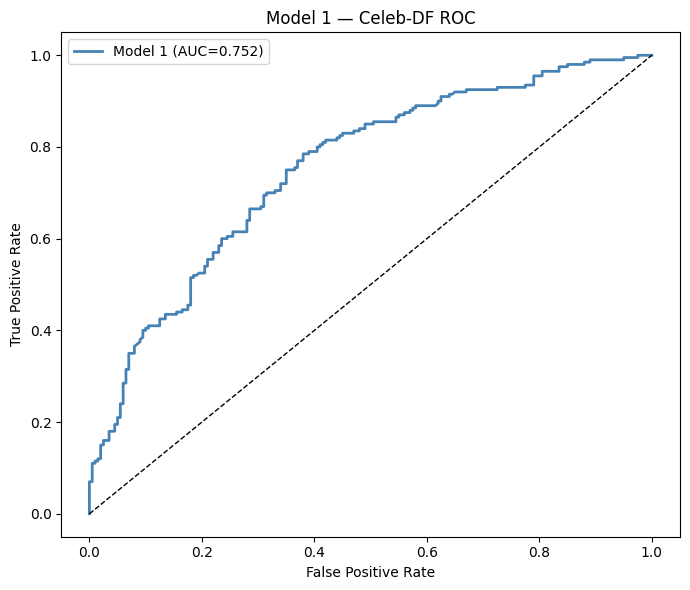

Results saved to /kaggle/working/deepfake_project/results/model1


In [11]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import threading
from concurrent.futures import ThreadPoolExecutor

# CascadeClassifier is NOT thread-safe — each decoder thread gets its own copy
_tls = threading.local()
_fallback_count = [0, 0]   # [fallbacks, total]

def _get_cascade():
    if not hasattr(_tls, 'cascade'):
        _tls.cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    return _tls.cascade

def _crop_face(frame, margin=0.3):
    """Largest detected face + margin; falls back to center square crop."""
    _fallback_count[1] += 1
    gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    faces = _get_cascade().detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(60, 60))
    H, W = frame.shape[:2]
    if len(faces) > 0:
        x, y, w, h = max(faces, key=lambda f: f[2] * f[3])
        m = int(margin * max(w, h))
        return frame[max(0, y-m):min(H, y+h+m), max(0, x-m):min(W, x+w+m)]
    _fallback_count[0] += 1
    side = min(H, W); y0, x0 = (H - side) // 2, (W - side) // 2
    return frame[y0:y0+side, x0:x0+side]

def _decode_frames(vpath, n_frames):
    """Decode n evenly spaced frames, face-crop each."""
    cap   = cv2.VideoCapture(str(vpath))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total == 0:
        cap.release(); return None
    want   = set(np.linspace(0, total - 1, n_frames, dtype=int).tolist())
    frames, idx = [], 0
    while idx <= max(want) and cap.grab():
        if idx in want:
            ret, frame = cap.retrieve()
            if ret:
                face = _crop_face(frame)
                frames.append(cv2.cvtColor(cv2.resize(face, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB))
        idx += 1
    cap.release()
    return frames or None

def predict_video_batch(vpaths, model, tf, device, n_frames=32, decode_workers=4, frame_fn=None):
    """Decode in parallel threads, score each video's frames in one forward pass.
    Optional frame_fn(rgb)->rgb applied to each cropped frame (for ablations)."""
    model.eval()
    results = [None] * len(vpaths)
    def _decode(p):
        fr = _decode_frames(p, n_frames)
        if fr and frame_fn is not None:
            fr = [frame_fn(f) for f in fr]
        return fr
    with ThreadPoolExecutor(max_workers=decode_workers) as ex, torch.no_grad():
        for i, frames in enumerate(ex.map(_decode, vpaths)):
            if not frames: continue
            batch = torch.stack([tf(image=f)['image'] for f in frames]).to(device)
            with autocast('cuda'):
                probs = torch.sigmoid(model(batch))
            results[i] = float(probs.mean().item())
    print(f"Haar fallback: {_fallback_count[0]}/{_fallback_count[1]} frames "
          f"({100*_fallback_count[0]/max(1,_fallback_count[1]):.1f}%)")
    return results

real_vids = []
for d in CELEBDF_REAL_DIRS:
    real_vids += list(Path(d).rglob('*.mp4'))
fake_vids = list(Path(CELEBDF_FAKE_DIR).rglob('*.mp4'))
print(f"Real: {len(real_vids)} | Fake: {len(fake_vids)}")

if not real_vids or not fake_vids:
    print("Celeb-DF videos not found — skipping eval.")
else:
    model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth', map_location=device, weights_only=False))
    scores, labels = [], []
    for vids, lab, name in [(real_vids[:EVAL_N_PER_CLASS], 1, 'Real'),
                            (fake_vids[:EVAL_N_PER_CLASS], 0, 'Fake')]:
        res = predict_video_batch(vids, model, val_tf, device, n_frames=EVAL_N_FRAMES)
        for s_ in res:
            if s_ is not None: scores.append(s_); labels.append(lab)
        print(f"{name}: scored {sum(r is not None for r in res)}/{len(vids)}")

    auc = roc_auc_score(labels, scores)
    print(f"\nCeleb-DF AUC: {auc:.4f}")
    if auc < 0.75:
        print("WARNING: below 0.75 — check eval preprocessing matches training.")

    fpr, tpr, _ = roc_curve(labels, scores)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f'Model 1 (AUC={auc:.3f})', color='steelblue', lw=2)
    plt.plot([0,1],[0,1],'k--', lw=1)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('Model 1 — Celeb-DF ROC'); plt.legend(); plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/roc_celebdf.png', dpi=150); plt.show()

    with open(f'{RESULTS_DIR}/celebdf_eval.json', 'w') as f:
        json.dump({'auc': round(auc,4), 'n_real': labels.count(1), 'n_fake': labels.count(0),
                   'run_tag': RUN_TAG}, f, indent=2)
    print(f"Results saved to {RESULTS_DIR}")

## Diagnostic: does JPEG re-compression still bias scores?
Sanity check that `_shared_degrade` killed the compression shortcut. Self-contained (no monkeypatch). Means should be close.

In [12]:
if real_vids and fake_vids:
    def _jpeg(img):
        q = random.randint(30, 90)
        _, buf = cv2.imencode('.jpg', cv2.cvtColor(img, cv2.COLOR_RGB2BGR),
                              [cv2.IMWRITE_JPEG_QUALITY, q])
        return cv2.cvtColor(cv2.imdecode(buf, cv2.IMREAD_COLOR), cv2.COLOR_BGR2RGB)

    test_vids = real_vids[:50]
    clean = predict_video_batch(test_vids, model, val_tf, device, n_frames=EVAL_N_FRAMES)
    jpeg  = predict_video_batch(test_vids, model, val_tf, device, n_frames=EVAL_N_FRAMES, frame_fn=_jpeg)
    c = [s for s in clean if s is not None]
    j = [s for s in jpeg  if s is not None]
    print(f"clean mean score: {np.mean(c):.3f}  |  jpeg mean score: {np.mean(j):.3f}  "
          f"(delta {np.mean(c)-np.mean(j):+.3f}; near 0 = shortcut removed)")
else:
    print("Celeb-DF videos absent — skipping diagnostic.")

Haar fallback: 311/14400 frames (2.2%)
Haar fallback: 366/16000 frames (2.3%)
clean mean score: 0.508  |  jpeg mean score: 0.667  (delta -0.159; near 0 = shortcut removed)


## Cross-Scope Check: ROSE (presentation attacks)
Model 1 is a blend-artifact detector; replay/print attacks contain a *genuine* face, so the
**expected result is ~0.5 AUC**. This is the complementarity check for the fusion story
(mirror of Model 2 on Celeb-DF), not part of the 0.80 target. AUC well above 0.5 suggests a
texture/recapture shortcut survived — investigate before claiming clean scope separation.

In [13]:
GENUINE_CODES = {'g', 'genuine', 'real', 'live'}
ATTACK_CODES  = {'ps', 'pq', 'vl', 'vm', 'mc', 'mf', 'mu', 'attack', 'fake', 'spoof'}
VID_EXTS      = ('.mp4', '.avi', '.mov', '.mkv')

def _rose_label(p):
    parts = [s.lower() for s in p.parts[-3:-1]]
    for s in parts:
        if s in GENUINE_CODES: return 1
        if s in ATTACK_CODES:  return 0
    toks = p.stem.lower().replace('-', '_').split('_')
    for t in toks:
        if t in ATTACK_CODES: return 0
    if 'g' in toks: return 1
    return None

ROSE_ROOT = None
for root in [Path('/kaggle/input'), Path(f'{BASE}/datasets')]:
    if not root.exists(): continue
    hits = [p for p in root.iterdir() if 'rose' in p.name.lower()]
    if hits: ROSE_ROOT = hits[0]; break

if ROSE_ROOT is None:
    print("ROSE not found — skipping cross-scope check.")
else:
    vids = [p for p in ROSE_ROOT.rglob('*') if p.suffix.lower() in VID_EXTS]
    genuine = [p for p in vids if _rose_label(p) == 1]
    attacks = [p for p in vids if _rose_label(p) == 0]
    print(f"ROSE @ {ROSE_ROOT}: {len(genuine)} genuine | {len(attacks)} attack | "
          f"{len(vids)-len(genuine)-len(attacks)} unlabelled (ignored)")
    if not genuine or not attacks:
        print("Could not derive both classes — skipping. Check layout / adjust _rose_label().")
    else:
        N = 150
        random.seed(SEED)
        g_s = random.sample(genuine, min(N, len(genuine)))
        a_s = random.sample(attacks, min(N, len(attacks)))
        model.load_state_dict(torch.load(f'{MODEL_DIR}/best.pth', map_location=device))
        g_scores = [s for s in predict_video_batch(g_s, model, val_tf, device, n_frames=16) if s is not None]
        a_scores = [s for s in predict_video_batch(a_s, model, val_tf, device, n_frames=16) if s is not None]
        y = [1]*len(g_scores) + [0]*len(a_scores)
        rose_auc = roc_auc_score(y, g_scores + a_scores)
        print(f"\nROSE cross-scope AUC: {rose_auc:.4f}  (expected ~0.5 by design)")
        print(f"  genuine mean: {np.mean(g_scores):.3f} | attack mean: {np.mean(a_scores):.3f}")
        if rose_auc > 0.65:
            print("  NOTE: well above chance — a texture/recapture shortcut may persist.")
        with open(f'{RESULTS_DIR}/rose_crossscope.json', 'w') as f:
            json.dump({'auc': round(rose_auc, 4), 'n_genuine': len(g_scores), 'n_attack': len(a_scores),
                       'genuine_mean': round(float(np.mean(g_scores)), 4),
                       'attack_mean':  round(float(np.mean(a_scores)), 4),
                       'framing': 'cross-scope complementarity check; ~0.5 expected; NOT part of Celeb-DF target'}, f, indent=2)
        print(f"Saved -> {RESULTS_DIR}/rose_crossscope.json")

ROSE not found — skipping cross-scope check.
